In [1]:
import torch
from pathlib import Path
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import math

In [2]:
p_obj = Path('/data/soyeonhong/vq2d/vq2d-lightning/outputs/yolo')

clip_uids = list(p_obj.glob('*.pt'))
p_ex = p_obj / f'{clip_uids[0].stem}.pt'
ex = torch.load(p_ex, weights_only=True)

print(ex[0])
print(f'\nFrame idx: {ex[0][0]}')
print(f'The number of boxes: {ex[0][1]}')
print(f'Box: {ex[0][2]}')
print(f'confidence: {ex[0][3]}')
print(f'Class: {ex[0][4]}')

(1, 3, tensor([[345.1063, 161.4924,  73.6401, 163.8925],
        [ 80.2402, 124.1515,  72.2772,  76.0241],
        [285.3972, 172.1836, 565.8658, 280.7273]]), tensor([0.3360, 0.2959, 0.2511]), ['hot dog', 'cup', 'dining table'])

Frame idx: 1
The number of boxes: 3
Box: tensor([[345.1063, 161.4924,  73.6401, 163.8925],
        [ 80.2402, 124.1515,  72.2772,  76.0241],
        [285.3972, 172.1836, 565.8658, 280.7273]])
confidence: tensor([0.3360, 0.2959, 0.2511])
Class: ['hot dog', 'cup', 'dining table']


In [3]:
p_train = Path('/data/soyeonhong/vq2d/vq2d-lightning/data/vq_v2_train_anno.json')
p_val = Path('/data/soyeonhong/vq2d/vq2d-lightning/data/vq_v2_val_anno.json')
ann_train = json.loads(p_train.read_text())
ann_val = json.loads(p_val.read_text())

ann_train[0]

{'video_uid': '56a3b49c-6979-4253-9ff5-2733c3e2f229',
 'clip_uid': '3fe39989-54ed-4a3a-bea4-88be05ff8df7',
 'annotation_uid': 'c64628fc-f163-4eb6-b7b1-f89b35cdcf54',
 'query_set': '1',
 'clip_fps': 5.0,
 'clip_duration': 300.00000000000006,
 'original_width': 1440,
 'original_height': 1080,
 'query_frame': 1190,
 'object_title': 'mr krips',
 'visual_crop': {'fno': 1198,
  'x': 742.08,
  'y': 587.21,
  'w': 78.35,
  'h': 121.73},
 'response_track_valid_range': [1099, 1109],
 'response_track': [{'fno': 1099,
   'x': 929.68,
   'y': 540.42,
   'w': 11.2,
   'h': 41.4},
  {'fno': 1100, 'x': 917.51, 'y': 542.37, 'w': 12.18, 'h': 43.34},
  {'fno': 1101, 'x': 910.69, 'y': 546.26, 'w': 12.18, 'h': 48.12},
  {'fno': 1102, 'x': 930.17, 'y': 544.32, 'w': 18.51, 'h': 51.9},
  {'fno': 1103, 'x': 966.7, 'y': 547.33, 'w': 17.23, 'h': 56.89},
  {'fno': 1104, 'x': 1004.2, 'y': 557.32, 'w': 21.08, 'h': 62.97},
  {'fno': 1105, 'x': 1032.44, 'y': 549.99, 'w': 24.4, 'h': 74.68},
  {'fno': 1106, 'x': 1066.6

In [4]:
obj_data_per_query = {}
obj_data_per_clip = {}
for ann in tqdm(ann_val):
    clip_uid = ann['clip_uid']
    annotation_uid = ann['annotation_uid']
    query_set = ann['query_set']
    query_id = f'{annotation_uid}_{query_set}'
    rt_range = ann['response_track_valid_range']
    rt_start = rt_range[0]
    rt_end = rt_range[1]
    
    p_clip_obj = p_obj / f'{clip_uid}.pt'
    obj_data = torch.load(p_clip_obj, weights_only=True)
    
    obj_count = []
    obj_count_rt = []
    for data in obj_data:
        frame_idx = data[0]
        num_obj = data[1]
        obj_count.append(num_obj)
        if rt_start + 1 <= frame_idx <= rt_end:
            obj_count_rt.append(num_obj)
    
    # obj_count = np.array(obj_count)
    # obj_count_rt = np.array(obj_count_rt)
    # obj_count_mean = np.mean(obj_count)
    
    # if not clip_uid in list(obj_data_per_clip.keys()):
    #     obj_data_per_clip[clip_uid] = {'obj_count': obj_count,
    #                                    'obj_count_mean': obj_count_mean}
    if not math.isnan(np.mean(obj_count_rt)):
        obj_data_per_query[query_id] = {
                'obj_count': obj_count_rt,
                'obj_count_mean': np.mean(np.array(obj_count_rt))}

  0%|          | 0/4504 [00:00<?, ?it/s]

  3%|▎         | 134/4504 [00:46<18:54,  3.85it/s]/data/soyeonhong/anaconda3/envs/vq2d-lightning/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/data/soyeonhong/anaconda3/envs/vq2d-lightning/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 4504/4504 [23:56<00:00,  3.14it/s]


In [6]:
# json dump the data
json.dump(obj_data_per_query, open('obj_data_per_query.json', 'w'))

In [42]:
import math

mean_obj_rt = []
for query_id in list(obj_data_per_query.keys()):
    if not math.isnan(obj_data_per_query[query_id]['obj_count_in_rt_mean']):    
        mean_obj_rt.append(obj_data_per_query[query_id]['obj_count_in_rt_mean'])
    else:
        print(query_id, obj_data_per_query[query_id]['obj_count_in_rt_mean'])

39a1bbb0-49da-4521-a3be-57b7bf6e7553_1 nan


In [5]:
mean_obj_clip = []
for clip_uid in list(obj_data_per_clip.keys()):
    mean_obj_clip.append(obj_data_per_clip[clip_uid]['obj_count_mean'])

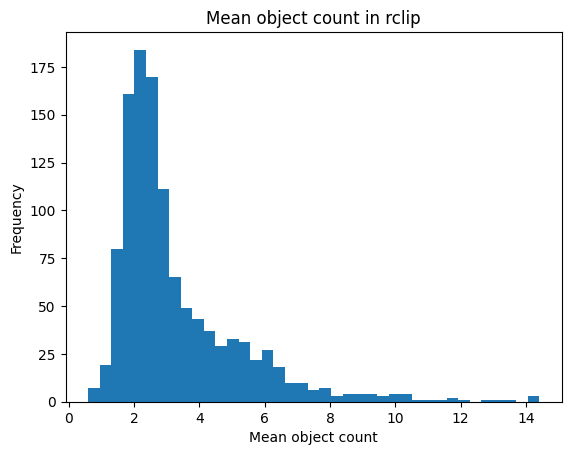

In [44]:
plt.hist(mean_obj_clip, bins='auto')
plt.title('Mean object count in rclip')
plt.xlabel('Mean object count')
plt.ylabel('Frequency')

plt.show()

In [6]:
print(f'max: {np.max(mean_obj_clip)}')
print(f'min: {np.min(mean_obj_clip)}')
print(f'mean: {np.mean(mean_obj_clip)}')
print(f'std: {np.std(mean_obj_clip)}')
print(f'33 percentile: {np.percentile(mean_obj_clip, 33)}')
print(f'66 percentile: {np.percentile(mean_obj_clip, 66)}')

max: 14.401499375260308
min: 0.5916055962691539
mean: 3.300774982378737
std: 1.9611156259617288
33 percentile: 2.2219720907982765
66 percentile: 3.2313869221157856


In [10]:
less = []
medium = []
many = []
for query_id in list(obj_data_per_clip.keys()):
    mean = obj_data_per_clip[query_id]['obj_count_mean']
    percentile_33 = np.percentile(mean_obj_clip, 33)
    percentile_66 = np.percentile(mean_obj_clip, 66)
    if not math.isnan(mean):
        if mean < percentile_33:
            less.append(query_id)
        elif percentile_33 <= mean < percentile_66:
            medium.append(query_id)
        else:
            many.append(query_id)

num_obj_data = {
    'less': less,
    'medium': medium,
    'many': many
}

# json dump
p_num_obj_data = Path('/data/soyeonhong/vq2d/vq2d-lightning/outputs/num_obj_data_in_clip.json')       
p_num_obj_data.write_text(json.dumps(num_obj_data))

46312

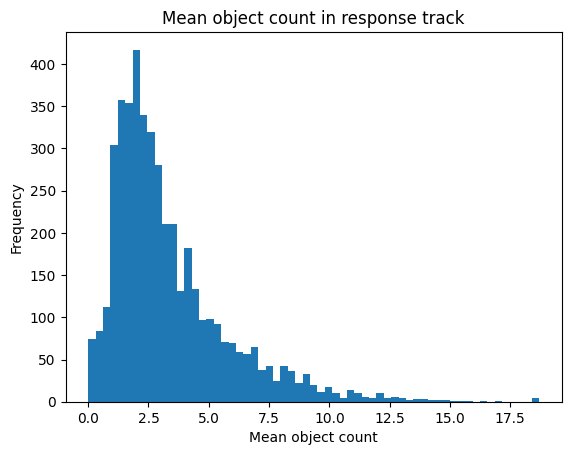

In [46]:
plt.hist(mean_obj_rt, bins='auto')
plt.title('Mean object count in response track')
plt.xlabel('Mean object count')
plt.ylabel('Frequency')

plt.show()

In [14]:
mean_obj_rt= []
for clip_uid in list(obj_data_per_query.keys()):
    mean_obj_rt.append(obj_data_per_query[clip_uid]['obj_count_mean'])

In [15]:
print(f'max: {np.max(mean_obj_rt)}')
print(f'min: {np.min(mean_obj_rt)}')
print(f'mean: {np.mean(mean_obj_rt)}')
print(f'std: {np.std(mean_obj_rt)}')
print(f'33 percentile: {np.percentile(mean_obj_rt, 33)}')
print(f'66 percentile: {np.percentile(mean_obj_rt, 66)}')

max: 18.7
min: 0.0
mean: 3.3621547951997814
std: 2.452953149928631
33 percentile: 2.0
66 percentile: 3.5714285714285716


In [49]:
less = []
medium = []
many = []
for query_id in list(obj_data_per_query.keys()):
    mean = obj_data_per_query[query_id]['obj_count_in_rt_mean']
    percentile_33 = np.percentile(mean_obj_rt, 33)
    percentile_66 = np.percentile(mean_obj_rt, 66)
    if not math.isnan(mean):
        if mean < percentile_33:
            less.append(query_id)
        elif percentile_33 <= mean < percentile_66:
            medium.append(query_id)
        else:
            many.append(query_id)

num_obj_data = {
    'less': less,
    'medium': medium,
    'many': many
}

# json dump
p_num_obj_data = Path('/data/soyeonhong/vq2d/vq2d-lightning/outputs/num_obj_data_in_rt.json')       
p_num_obj_data.write_text(json.dumps(num_obj_data))

189158